In [48]:
"""
Q1. Data Loading & Understanding

a) Load the dataset into Python.
b) Display the first 5 rows.
c) Check the shape of the dataset.
d) Display the data types of each column.
"""
import pandas as pd
df2=pd.read_csv(r"C:\Users\91630\Downloads\loan_approval - loan_approval.csv")
print(df2.head())
print(df2.shape)
df2.info()



              name              city  income  credit_score  loan_amount  \
0     Allison Hill         East Jill  113810           389        39698   
1     Brandon Hall     New Jamesside   44592           729        15446   
2     Rhonda Smith      Lake Roberto   33278           584        11189   
3  Gabrielle Davis  West Melanieview  127196           344        48823   
4     Valerie Gray         Mariastad   66048           496        47174   

   years_employed  points  loan_approved  
0              27      50          False  
1              28      55          False  
2              13      45          False  
3              29      50          False  
4               4      25          False  
(2000, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   name            2000 non-null   object
 1   city            2000 non-null   object

In [49]:
"""
Q2. Data Cleaning

a) Check for missing values in the dataset.
b) Handle missing values appropriately.
c) Identify categorical columns present in the dataset.
"""
df2.isnull().sum()
# there are no missing values in the dataset
categorical_cols=df2.select_dtypes(include=['object','category']).columns
print(categorical_cols)




Index(['name', 'city'], dtype='object')


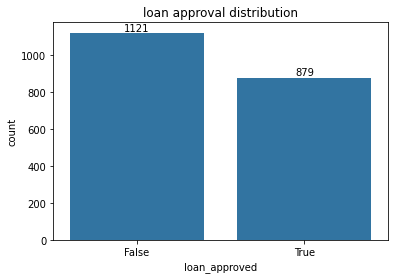

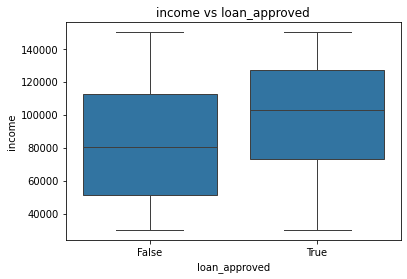

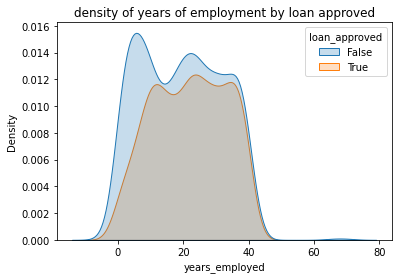

In [50]:
"""
Q3. Exploratory Data Analysis (EDA)

a) Plot the distribution of the target variable.
b) Analyze the relationship between one numerical feature and the target variable.
c) Analyze the relationship between Years of Employment and the target variable.
"""
import seaborn as sns
import matplotlib.pyplot as plt
ax=sns.countplot(x='loan_approved',data=df2)
for container in ax.containers:
    ax.bar_label(container)
plt.title('loan approval distribution')
plt.show()
#loan rejection is higher compared to approved loans
sns.boxplot(x='loan_approved',y='income',data=df2)
plt.title('income vs loan_approved')
plt.show()
# here the median for high income and true cases for laon approval is high than median of slightly less income and false cases,which shows high income corresponds to more loan approvals
sns.kdeplot(data=df2,x='years_employed',hue='loan_approved',fill=True)
plt.title('density of years of employment by loan approved')
plt.show()
#plot shows higher the years of employment more are the chances of loan being approved

In [51]:
"""
Q4. Outlier Detection and Treatment
a) Detect outliers in numerical columns using the IQR method.
b) Treat outliers using capping techniques
"""
import pandas as pd
import numpy as np
num_cols=df2.select_dtypes(include=[np.number]).columns
for col in num_cols:
    Q1=df2[col].quantile(0.25)
    Q3=df2[col].quantile(0.75)
    IQR=Q3-Q1
    lower_bound=Q1-1.5*IQR
    upper_bound=Q3+1.5*IQR
    outliers=df2[(df2[col]<lower_bound)|df2[col]>upper_bound][col]
    print(f"Number of Outliers: {len(outliers)}")
    print("Outlier Values:")
    print(outliers.values)
    #applying capping here,i.e,winsorization
    df2[col] = np.where(df2[col] < lower_bound, lower_bound,
    np.where(df2[col] > upper_bound, upper_bound, df[col]))


Number of Outliers: 0
Outlier Values:
[]
Number of Outliers: 0
Outlier Values:
[]
Number of Outliers: 0
Outlier Values:
[]
Number of Outliers: 0
Outlier Values:
[]
Number of Outliers: 0
Outlier Values:
[]


In [55]:
#Q5. Convert target variables into numerical format suitable for model building and drop unnecessary
#columns.
df2.columns = df2.columns.str.strip().str.lower().str.replace(' ', '_')

print(df2.columns)  # confirm target column name

df2['loan_approved'] = (
    df2['loan_approved']
    .astype(str)
    .str.strip()
    .str.upper()
    .map({'TRUE': 1, 'FALSE': 0})
)

df2 = df2.drop(['name','city'], axis=1, errors='ignore')
df2.head()


Index(['income', 'credit_score', 'loan_amount', 'years_employed', 'points',
       'loan_approved'],
      dtype='object')


,income,credit_score,loan_amount,years_employed,points,loan_approved
0,113810.0,389.0,39698.0,27.0,50.0,NaN
1,44592.0,729.0,15446.0,28.0,55.0,NaN
2,33278.0,584.0,11189.0,13.0,45.0,NaN
3,127196.0,344.0,48823.0,29.0,50.0,NaN
4,66048.0,496.0,47174.0,4.0,25.0,NaN


In [59]:
"""
Q6. Feature Selection and Data Splitting

a) Separate independent variables (X) and dependent variable (y)
b) Split the dataset into training and testing sets.
"""
y=df2['loan_approved']
x=df2.drop('loan_approved',axis=1)
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)


(1600, 5) (400, 5)
(1600,) (400,)


In [61]:
#Q7. Apply feature scaling to the dataset using StandardScaler.
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train_scaled=scaler.fit_transform(x_train)
x_test_scaled=scaler.transform(x_test)
print(x_train_scaled.mean()) 
print(x_train_scaled.std())


3.552713678800501e-18
1.0


In [63]:
"""
Q8. Logistic Regression Model Building
a) Train a Logistic Regression model.
b) Predict the output for test data.
"""
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
model=LogisticRegression()
model.fit(x_train_scaled,y_train)
y_pred=model.predict(x_test_scaled)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.9975
Confusion Matrix:
 [[104   1]
 [  0 295]]
Classification Report:
               precision    recall  f1-score   support

           0       1.00      0.99      1.00       105
           1       1.00      1.00      1.00       295

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [65]:
"""
Q9. Model Evaluation - Confusion Matrix
a) Generate the confusion matrix.
b) Interpret the results.
"""
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
print(cm)
# On interpretin the matrix we get to know that True negative value=104,false positive value=1,false negative value=0,True positive value=295


[[104   1]
 [  0 295]]


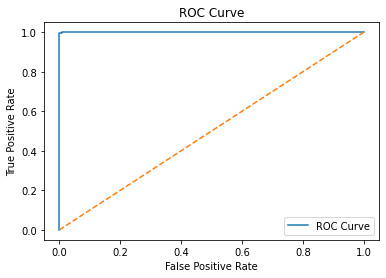

AUC Score: 0.9999677158999193


In [67]:
"""
Q10. Model Evaluation - ROC Curve & AUC
a) Plot the ROC curve.
b) Calculate the AUC score.
"""
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt
y_prob = model.predict_proba(x_test_scaled)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
plt.plot(fpr, tpr, label='ROC Curve')
plt.plot([0, 1], [0, 1], linestyle='--')  
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

auc_score = roc_auc_score(y_test, y_prob)
print("AUC Score:", auc_score)

